<a href="https://colab.research.google.com/github/preetbhagat7/Gender_Name_Classification/blob/main/XG_Boost_Name.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [129]:
#import lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from xgboost import XGBClassifier
import shap

In [130]:
# Load Data

from google.colab import files
uploaded = files.upload()  # Upload your CSV
csv_file = list(uploaded.keys())[0]
df = pd.read_csv(csv_file)

df.head()

Saving untitled query_2025-12-24 (10).csv to untitled query_2025-12-24 (10) (1).csv


/tmp/ipython-input-1485247172.py:6: DtypeWarning: Columns (18,45) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)


,s.session_id,last_event_timestamp,s.brand,s.user_id,device_tier,device_name,device_recency,device_manufacturer,user_agent,session_start_time,...,last_page_path,feature_provider,payment_method,is_returned,element_id,financial_status,fulfillment_status,tags,checkout_token,compare_at_price
0,f524db87-226c-4fa8-876f-dfd0c25ef31f,2025-12-24 10:29:57,w-for-women,03fd970f-c170-426e-a033-0b44405308c8,3.0,Apple iPhone 13,3.0,Apple,Mozilla/5.0 (iPhone; CPU iPhone OS 18_1_1 like...,2025-12-24 10:29:57,...,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,0
1,0ec248fc-c118-46e2-880f-3facaa3c64ec,2025-12-24 10:29:57,w-for-women,socv0zlsgh8-4voxgte1oj7-yfdyvdrnes-u9w4xepcykr,4.0,A3x 5G,4.0,Oppo,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,2025-12-24 10:29:50,...,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,0
2,a7aeea3c-13a2-455b-9216-bebc66375568,2025-12-24 10:29:37,w-for-women,69c7dd7b-610e-4e67-b4ca-da1a884a39e4,3.0,Apple iPhone 13,3.0,Apple,Mozilla/5.0 (iPhone; CPU iPhone OS 18_5 like M...,2025-12-24 10:29:33,...,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,0
3,df2c6671-86d4-4339-a58c-520b661271e0,2025-12-24 10:28:12,w-for-women,a271cb84-e1b5-409f-b768-93f7ed142bc6,4.0,Apple iPhone 15 Pro,5.0,Apple,Mozilla/5.0 (iPhone; CPU iPhone OS 18_7 like M...,2025-12-24 10:28:00,...,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,0
4,52e4f548-0e84-46fb-961a-2c7dda5633f3,2025-12-24 10:29:58,w-for-women,e6e65f7f-b393-4452-a667-5c672650cdab,3.0,Apple iPhone 13,3.0,Apple,Mozilla/5.0 (iPhone; CPU iPhone OS 18_6 like M...,2025-12-24 10:26:56,...,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,0


In [131]:
#  Extract Full Name from JSON Column

def get_combined_name(json_str):
    try:
        data = json.loads(json_str)
        address = data.get('address', {})
        first = address.get('first_name', '').strip()
        last  = address.get('last_name', '').strip()
        full_name = f"{first} {last}".strip()
        return full_name if full_name else "Unknown"
    except Exception:
        return "Invalid Data"

df['full_name'] = df['gtag_user_data'].apply(get_combined_name)
print(df[['gtag_user_data', 'full_name']].head())

                                      gtag_user_data  \
0  {"email":"8500877751@example.com","phone_numbe...   
1  {"email":"ggrnirinathan@gmail.com","phone_numb...   
2  {"email":"Sameeeamaakani123@gmail.com","phone_...   
3  {"email":"sinha.aakriti27@gmail.com","phone_nu...   
4  {"email":"singh.shreya0714@gmail.com","phone_n...   

                                           full_name  
0  FlatNo Shalom Heights OU Colony Shaikpet Hyder...  
1                                GURURAKSHA NIRANJAN  
2                                    Sameera maakani  
3                                      Aakriti Sinha  
4                                            Unknown  


In [132]:
# 3 Predict Gender from Name

print("Upload your name_gender.json:")
uploaded_json = files.upload()
js_file_name = list(uploaded_json.keys())[0]
db = json.loads(uploaded_json[js_file_name].decode('utf-8'))

def predict_gender(name, database):
    raw_name = str(name).strip()
    full_name = raw_name.lower()
    if full_name in ["unknown", "invalid data"] or len(raw_name) < 2:
        return np.nan

    # Title detection
    if re.search(r'\b(mr|shri|shree|mister|master|msr)\b', full_name): return "male"
    if re.search(r'\b(mrs|ms|miss|smt|shrimati|कुमारी|shreemati|lady)\b', full_name): return "female"

    # Core name extraction
    parts = re.sub(r'\.', '', full_name).split()
    ignore = {'mr', 'mrs', 'ms', 'shri', 'smt', 'kumar', 'kumari', 'singh', 'devi', 'shree'}
    clean_tokens = [p for p in parts if p not in ignore]
    core_name = clean_tokens[0] if clean_tokens else ""
    if not core_name: return np.nan

    # Database lookup
    if core_name in database:
        entry = database[core_name]
        if isinstance(entry, str): return entry
        return "male" if entry.get('tier') == 1 else "female"

    # Suffix & pattern logic
    score_male, score_female = 0, 0
    male_suffixes = {'kumar','singh','prasad','nath','ji','lal','bhagat','son'}
    female_suffixes = {'kumari','devi','kaur','begum','shree','ben','didi'}
    for p in parts:
        if p in male_suffixes: score_male += 1.5
        if p in female_suffixes: score_female += 1.5
    if core_name.endswith(('a','i','ee')): score_female += 1.0
    else: score_male += 0.5

    if score_male == score_female: return np.nan
    return "male" if score_male > score_female else "female"

df['Gender'] = df['full_name'].apply(lambda x: predict_gender(x, db))
print(df['Gender'].value_counts(dropna=False))

Upload your name_gender.json:


Saving name_gender.json to name_gender (2).json
Gender
NaN       21430
female    15889
male       5484
Name: count, dtype: int64


In [176]:
# 4 Drop High-Cardinality / Leakage Columns

LEAKAGE_COLS = [
    "s.session_id","s.user_id","reference_ids","ip_address",
    "last_event_timestamp","session_start_time","session_end_time",
    "gtag_timestamp","timestamp","full_name","gtag_user_data",
    "utm_campaign","utm_id","form_info","ip_info"
]

df_ml = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns])

In [177]:
df.columns

Index(['s.session_id', 'last_event_timestamp', 's.brand', 's.user_id',
       'device_tier', 'device_name', 'device_recency', 'device_manufacturer',
       'user_agent', 'session_start_time', 'session_end_time', 'visit_count',
       'session_duration_sec', 'referrer_url', 'channel', 'utm_source',
       'utm_medium', 'utm_campaign', 'utm_term', 'utm_content', 'utm_id',
       'location_city', 'location_region', 'location_country',
       'location_city_tier', 'landing_page_path', 'landing_page_handle',
       'landing_page_type', 'is_bounced', 'is_engaged', 'has_add_to_cart',
       'has_purchase', 's.order_id', 'order_revenue', 'order_items_count',
       'person_score', 'intent_score', 'fit_score', 'os_name', 'os_version',
       'network_provider', 'ip_address', 'internet_speed', 'battery_level',
       'is_battery_charging', 'weather_condition', 'primary_language',
       'reference_ids', 'associated_region', 'ip_info', 'form_info', 'ip_data',
       'form_data', 'is_bot_session',

In [178]:
# 5️ Handle Missing Values

numeric_cols = df_ml.select_dtypes(include=['int64','float64']).columns
categorical_cols = df_ml.select_dtypes(include=['object','bool']).columns

# Fill numeric NaN with median
df_ml[numeric_cols] = df_ml[numeric_cols].fillna(df_ml[numeric_cols].median())
# Fill categorical NaN with 'missing'
df_ml[categorical_cols] = df_ml[categorical_cols].fillna('missing')

In [179]:
# 6️ Balance the Dataset

df_labeled = df_ml[df_ml["Gender"].notna()].copy()

male_df = df_labeled[df_labeled["Gender"]=="male"]
female_df = df_labeled[df_labeled["Gender"]=="female"]
min_size = min(len(male_df), len(female_df))

male_sample = resample(male_df, n_samples=min_size, random_state=42)
female_sample = resample(female_df, n_samples=min_size, random_state=42)

df_balanced = pd.concat([male_sample,female_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

# Encode target
le = LabelEncoder()
df_balanced["Gender"] = le.fit_transform(df_balanced["Gender"])


In [180]:
# Strip spaces from column names
df_balanced.columns = df_balanced.columns.str.strip()

# Now check again
print(df_balanced.columns)


Index(['s.brand', 'device_tier', 'device_name', 'device_recency',
       'device_manufacturer', 'user_agent', 'visit_count',
       'session_duration_sec', 'referrer_url', 'channel', 'utm_source',
       'utm_medium', 'utm_term', 'utm_content', 'location_city',
       'location_region', 'location_country', 'location_city_tier',
       'landing_page_path', 'landing_page_handle', 'landing_page_type',
       'is_bounced', 'is_engaged', 'has_add_to_cart', 'has_purchase',
       's.order_id', 'order_revenue', 'order_items_count', 'person_score',
       'intent_score', 'fit_score', 'os_name', 'os_version',
       'network_provider', 'internet_speed', 'battery_level',
       'is_battery_charging', 'weather_condition', 'primary_language',
       'associated_region', 'ip_data', 'form_data', 'is_bot_session',
       'is_engaged_session', 'is_bounced_session', 'o.order_id', 'hour_key',
       'o.user_id', 'o.session_id', 'cart_id', 'product_id', 'variant_id',
       'product_name', 'price_per_uni

In [144]:
# # 7 Feature Engineering: Aggregates & Time Features

# agg_cols = [
#     "session_duration_sec","visit_count","order_revenue",
#     "order_items_count","hour_key","has_purchase","has_add_to_cart",
#     "price_per_unit","quantity","line_item_discount","total_order_amount"
# ]

# # Aggregate stats per user using o.user_id
# agg_df = df_balanced.groupby("o.user_id")[agg_cols].agg(['mean','max','min','sum'])
# agg_df.columns = ['_'.join(col) for col in agg_df.columns]  # Flatten multi-level columns
# agg_df.reset_index(inplace=True)

# # Merge back to main dataframe
# df_balanced = df_balanced.merge(agg_df, on="o.user_id", how="left")

# # -------------------------------
# # Time Features
# # -------------------------------
# # Night user: 10 PM (22) to 5 AM (5) -> wrap around midnight
# df_balanced["is_night_user"] = df_balanced["hour_key"].apply(lambda x: 1 if (x >= 22 or x <= 5) else 0)

# # Work hour user: 9 AM to 6 PM (9-18)
# df_balanced["is_work_hour"] = df_balanced["hour_key"].between(9, 18).astype(int)

# # Long session: more than 10 minutes (600 sec)
# df_balanced["long_session"] = (df_balanced["session_duration_sec"] > 600).astype(int)

# print("✅ Aggregates and time features added successfully!")


✅ Aggregates and time features added successfully!


In [205]:
DROP_COLS_list = [
    # =========================
    # Identifiers (drop always)
    # =========================
    "s.session_id", "s.user_id", "o.user_id", "o.session_id",
    "cart_id", "product_id", "variant_id", "checkout_token",
    "reference_ids", "element_id", "ip_address",

    # =========================
    # Timestamps / tracking
    # =========================
    "last_event_timestamp", "session_start_time",
    "session_end_time", "gtag_timestamp", "timestamp",

    # =========================
    # Marketing / attribution
    # =========================
    "channel", "utm_source", "utm_medium", "utm_campaign",
    "utm_term", "utm_content", "utm_id", "referrer_url",

    # =========================
    # Text / high-cardinality
    # =========================
    "user_agent",
    "landing_page_path", "landing_page_handle", "landing_page_type",
    "tags", "product_name",
    "form_info", "form_data",
    "ip_info", "ip_data", "gtag_user_data",

    # =========================
    # Leakage / derived scores
    # =========================
    "person_score", "intent_score", "fit_score",

    # =========================
    # Order / post-outcome
    # =========================
    "s.order_id", "o.order_id",
    "payment_method", "financial_status",
    "fulfillment_status", "is_returned",
    "line_item_discount", "compare_at_price",

    # =========================
    # Name / PII (explicit)
    # =========================
    "full_name",

    "order_items_count", "order_revenue","s.brand", "weather_condition",
    "is_bot_session","quantity","country","pincode","o.brand","last_page_path",
    "feature_provider","has_purchase","has_add_to_cart"

]


In [206]:
# 8 Prepare Features & Target

DROP_COLS = ["DROP_COLS","Gender", "o.user_id", "o.session_id", "s.order_id"]
X = df_balanced.drop(columns=LEAKAGE_COLS+DROP_COLS+DROP_COLS_list, errors="ignore")
y = df_balanced["Gender"]

# Frequency encode remaining object columns
obj_cols = X.select_dtypes(include='object').columns
for col in obj_cols:
    freq_map = X[col].value_counts(normalize=True)
    X[col] = X[col].map(freq_map)

# Ensure no object columns remain
assert X.select_dtypes(include='object').empty

In [222]:
# # Combine features and target
# df_train_ready = X.copy()
# df_train_ready["Gender"] = y



In [223]:
# csv_path = "gender_training_dataset.csv"
# df_train_ready.to_csv(csv_path, index=False)

# print("Saved:", csv_path)


Saved: gender_training_dataset.csv


In [207]:
# Check the remaining columns
print("Number of features after dropping:", X.shape[1])
print("Columns:", X.columns.tolist())

Number of features after dropping: 28
Columns: ['device_tier', 'device_name', 'device_recency', 'device_manufacturer', 'visit_count', 'session_duration_sec', 'location_city', 'location_region', 'location_country', 'location_city_tier', 'is_bounced', 'is_engaged', 'os_name', 'os_version', 'network_provider', 'internet_speed', 'battery_level', 'is_battery_charging', 'primary_language', 'associated_region', 'is_engaged_session', 'is_bounced_session', 'hour_key', 'price_per_unit', 'total_order_amount', 'city', 'province', 'province_code']


In [208]:
# 9 Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Convert bools to int
bool_cols = X_train.select_dtypes(include='bool').columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

# Replace any infinite values
X_train.replace([np.inf,-np.inf], np.nan, inplace=True)
X_test.replace([np.inf,-np.inf], np.nan, inplace=True)

In [242]:
# 10 Train XGBoost Model

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=2,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.5,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.08, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1,
              num_parallel_tree=None, ...)

              precision    recall  f1-score   support

           0       0.84      0.81      0.82      1097
           1       0.82      0.85      0.83      1097

    accuracy                           0.83      2194
   macro avg       0.83      0.83      0.83      2194
weighted avg       0.83      0.83      0.83      2194

ROC-AUC: 0.9061183687341544
Top 15 features:
 location_country        0.071129
province_code           0.064585
os_name                 0.041384
is_battery_charging     0.041352
device_name             0.039770
province                0.037525
device_recency          0.037461
internet_speed          0.037153
device_manufacturer     0.036701
network_provider        0.036387
is_bounced              0.035672
location_city_tier      0.035565
os_version              0.035020
visit_count             0.035020
city                    0.034684
location_region         0.034402
associated_region       0.033886
primary_language        0.033807
location_city           0.033450


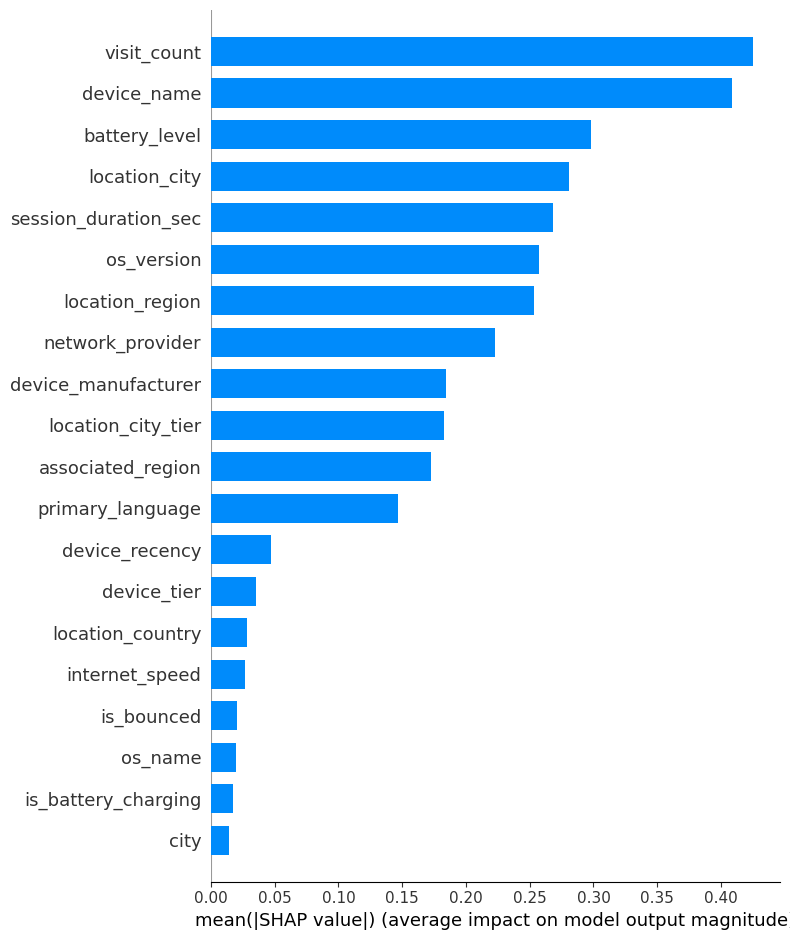

In [243]:
# 11 Evaluate Model

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# Feature Importance
importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Top 15 features:\n", importance.head(41))

# SHAP Summary
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train, plot_type="bar")


In [211]:
# Number of rows and columns
print("Shape of training data:", X_train.shape)
# Example output: (1755, 30) → 1755 rows, 30 columns


Shape of training data: (8774, 28)


In [212]:
print("Number of rows:", X_train.shape[0])


Number of rows: 8774


In [214]:
print("Number of columns:", X_train.shape[1])


Number of columns: 28


In [215]:
print("Columns in training data:", X_train.columns.tolist())


Columns in training data: ['device_tier', 'device_name', 'device_recency', 'device_manufacturer', 'visit_count', 'session_duration_sec', 'location_city', 'location_region', 'location_country', 'location_city_tier', 'is_bounced', 'is_engaged', 'os_name', 'os_version', 'network_provider', 'internet_speed', 'battery_level', 'is_battery_charging', 'primary_language', 'associated_region', 'is_engaged_session', 'is_bounced_session', 'hour_key', 'price_per_unit', 'total_order_amount', 'city', 'province', 'province_code']


In [216]:
X_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 8774 entries, 9771 to 1161
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   device_tier           8774 non-null   float64
 1   device_name           8774 non-null   float64
 2   device_recency        8774 non-null   float64
 3   device_manufacturer   8774 non-null   float64
 4   visit_count           8774 non-null   int64  
 5   session_duration_sec  8774 non-null   int64  
 6   location_city         8774 non-null   float64
 7   location_region       8774 non-null   float64
 8   location_country      8774 non-null   float64
 9   location_city_tier    8774 non-null   float64
 10  is_bounced            8774 non-null   int64  
 11  is_engaged            8774 non-null   int64  
 12  os_name               8774 non-null   float64
 13  os_version            8774 non-null   float64
 14  network_provider      8774 non-null   float64
 15  internet_speed        8

In [217]:
# Count of each class
print(y_train.value_counts())

# Ratio / percentage of each class
print(y_train.value_counts(normalize=True))


Gender
0    4387
1    4387
Name: count, dtype: int64
Gender
0    0.5
1    0.5
Name: proportion, dtype: float64


In [244]:
import pickle

# Save model
with open("gender_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved as gender_model.pkl")


Model saved as gender_model.pkl
